## Libraires

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re, string

nltk.download('stopwords')
nltk.download('punkt')

ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = [ps.stem(i) for i in text if i.isalnum() and i not in stopwords.words('english')]
    return " ".join(y)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MALATHIKA.P\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MALATHIKA.P\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Data

In [ ]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['target', 'text']
df['target'] = df['target'].map({'ham': 0, 'spam': 1})
df = df.drop_duplicates(keep='first')

df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(x.split()))
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


## Training

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['transformed_text']).toarray()

extra_features = df[['num_characters', 'num_words', 'num_sentences']].values

X = np.hstack((X_tfidf, extra_features))
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.ensemble import RandomForestClassifier

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(solver='liblinear'),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} -> Accuracy: {accuracy_score(y_test, y_pred):.4f}, Precision: {precision_score(y_test, y_pred):.4f}")

Naive Bayes -> Accuracy: 0.9729, Precision: 0.9916
Logistic Regression -> Accuracy: 0.9603, Precision: 0.9483
SVM -> Accuracy: 0.9758, Precision: 0.9478


Model Graph

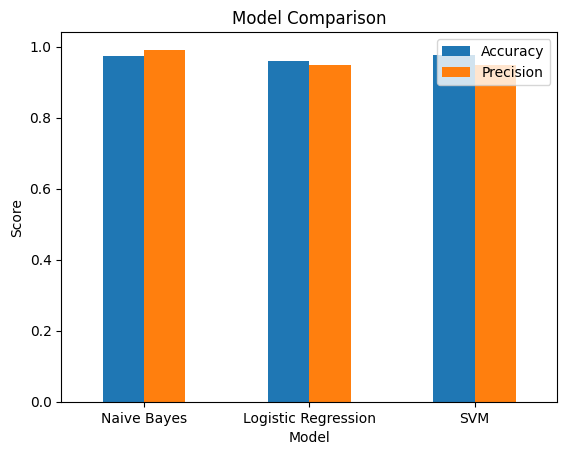

In [4]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)

    results.append([name, acc, prec])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision'])

results_df.set_index('Model').plot(kind='bar')
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## Confusion Matrix

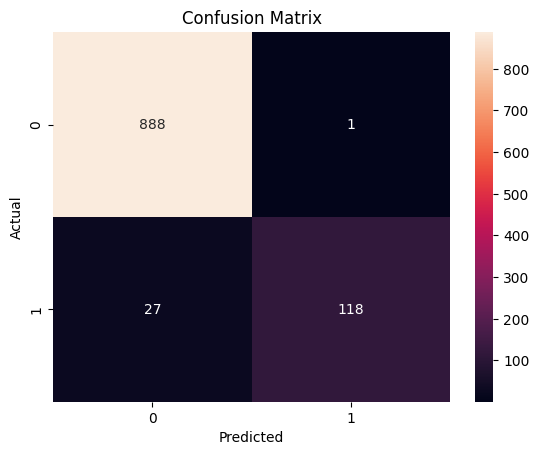

In [5]:
from sklearn.metrics import confusion_matrix

# Use any one model (best model recommend: Naive Bayes)
y_pred = models["Naive Bayes"].predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Save Model

In [ ]:
import pickle

model = models["Logistic Regression"]  # Best choice usually
model.fit(X_train, y_train)

pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(model, open('model.pkl', 'wb'))

## Load Model (Future Use)

In [7]:
import pickle

tfidf = pickle.load(open('vectorizer.pkl', 'rb'))
model = pickle.load(open('model.pkl', 'rb'))

## Visualization

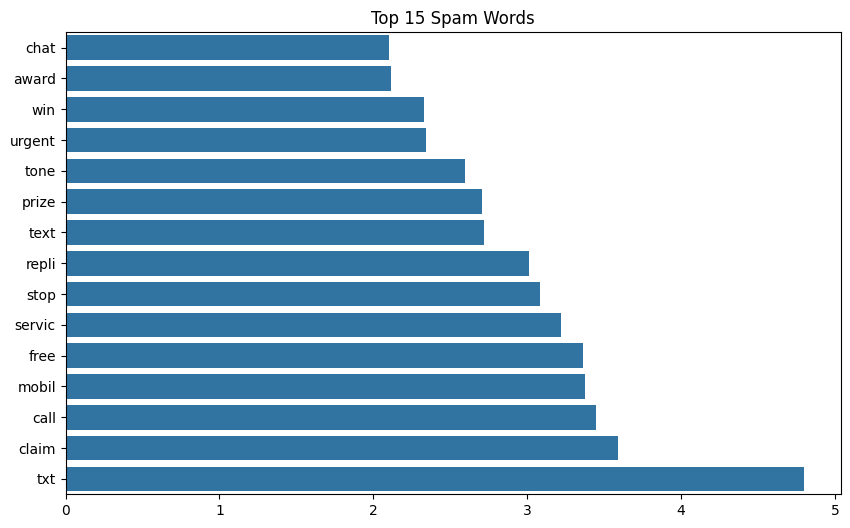

In [8]:
lr_model = models["Logistic Regression"]
words = tfidf.get_feature_names_out()
coeffs = lr_model.coef_[0]
top_indices = np.argsort(coeffs)[-15:]

plt.figure(figsize=(10, 6))
sns.barplot(x=[coeffs[i] for i in top_indices], y=[words[i] for i in top_indices])
plt.title("Top 15 Spam Words")
plt.show()

## Prediction

In [ ]:
def predict_mail(sample):
    processed = transform_text(sample)
    vector = tfidf.transform([processed]).toarray()

    extra = np.array([[len(sample), len(sample.split()), len(nltk.sent_tokenize(sample))]])

    final_input = np.hstack((vector, extra))

    prob = model.predict_proba(final_input)[0]

    if prob[1] > 0.6:
        return f"🚨 SPAM ({prob[1]*100:.2f}%)"
    else:
        return f"✅ HAM ({prob[0]*100:.2f}%)"

## Final Testing

In [10]:
my_test = input("Enter email: ")
print(predict_mail(my_test))

✅ HAM (96.05%)
